In [1]:
import pandas as pd

In [3]:
data = pd.read_csv('/content/heart.csv')

In [5]:
data.tail()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
1020,59,1,1,140,221,0,1,164,1,0.0,2,0,2,1
1021,60,1,0,125,258,0,0,141,1,2.8,1,1,3,0
1022,47,1,0,110,275,0,0,118,1,1.0,1,1,2,0
1023,50,0,0,110,254,0,0,159,0,0.0,2,0,2,1
1024,54,1,0,120,188,0,1,113,0,1.4,1,1,3,0


In [6]:
data.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1025.000000,1025.000000,1025.000000,1025.000000,1025.00000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000
mean,54.434146,0.695610,0.942439,131.611707,246.00000,0.149268,0.529756,149.114146,0.336585,1.071512,1.385366,0.754146,2.323902,0.513171
std,9.072290,0.460373,1.029641,17.516718,51.59251,0.356527,0.527878,23.005724,0.472772,1.175053,0.617755,1.030798,0.620660,0.500070
min,29.000000,0.000000,0.000000,94.000000,126.00000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,0.000000,120.000000,211.00000,0.000000,0.000000,132.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,56.000000,1.000000,1.000000,130.000000,240.00000,0.000000,1.000000,152.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,275.00000,0.000000,1.000000,166.000000,1.000000,1.800000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.00000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


In [9]:
X = data.iloc[:,:-1]

In [13]:
y = data.iloc[:,-1]

In [15]:
from sklearn.model_selection import train_test_split as tts

In [16]:
X_train, X_test, y_train, y_test = tts(X,y, train_size = 0.8, random_state= 44)

In [17]:
X_train.shape

(820, 13)

In [18]:
X_test.shape

(205, 13)

In [19]:
y_train.shape

(820,)

In [20]:
y_test.shape

(205,)

In [21]:
from sklearn.tree import DecisionTreeClassifier

In [22]:
model = DecisionTreeClassifier()

In [23]:
model.fit(X_train, y_train)

DecisionTreeClassifier()

In [24]:
y_pred = model.predict(X_test)

In [28]:
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score, precision_score, f1_score

In [29]:
accuracy_score(y_test,y_pred)

1.0

In [30]:
confusion_matrix(y_test, y_pred)

array([[111,   0],
       [  0,  94]])

In [31]:
recall_score(y_test, y_pred)

1.0

In [32]:
precision_score(y_test, y_pred)

1.0

In [33]:
f1_score(y_test, y_pred)

1.0

In [43]:
import matplotlib.pyplot as plt

In [44]:
from sklearn import tree

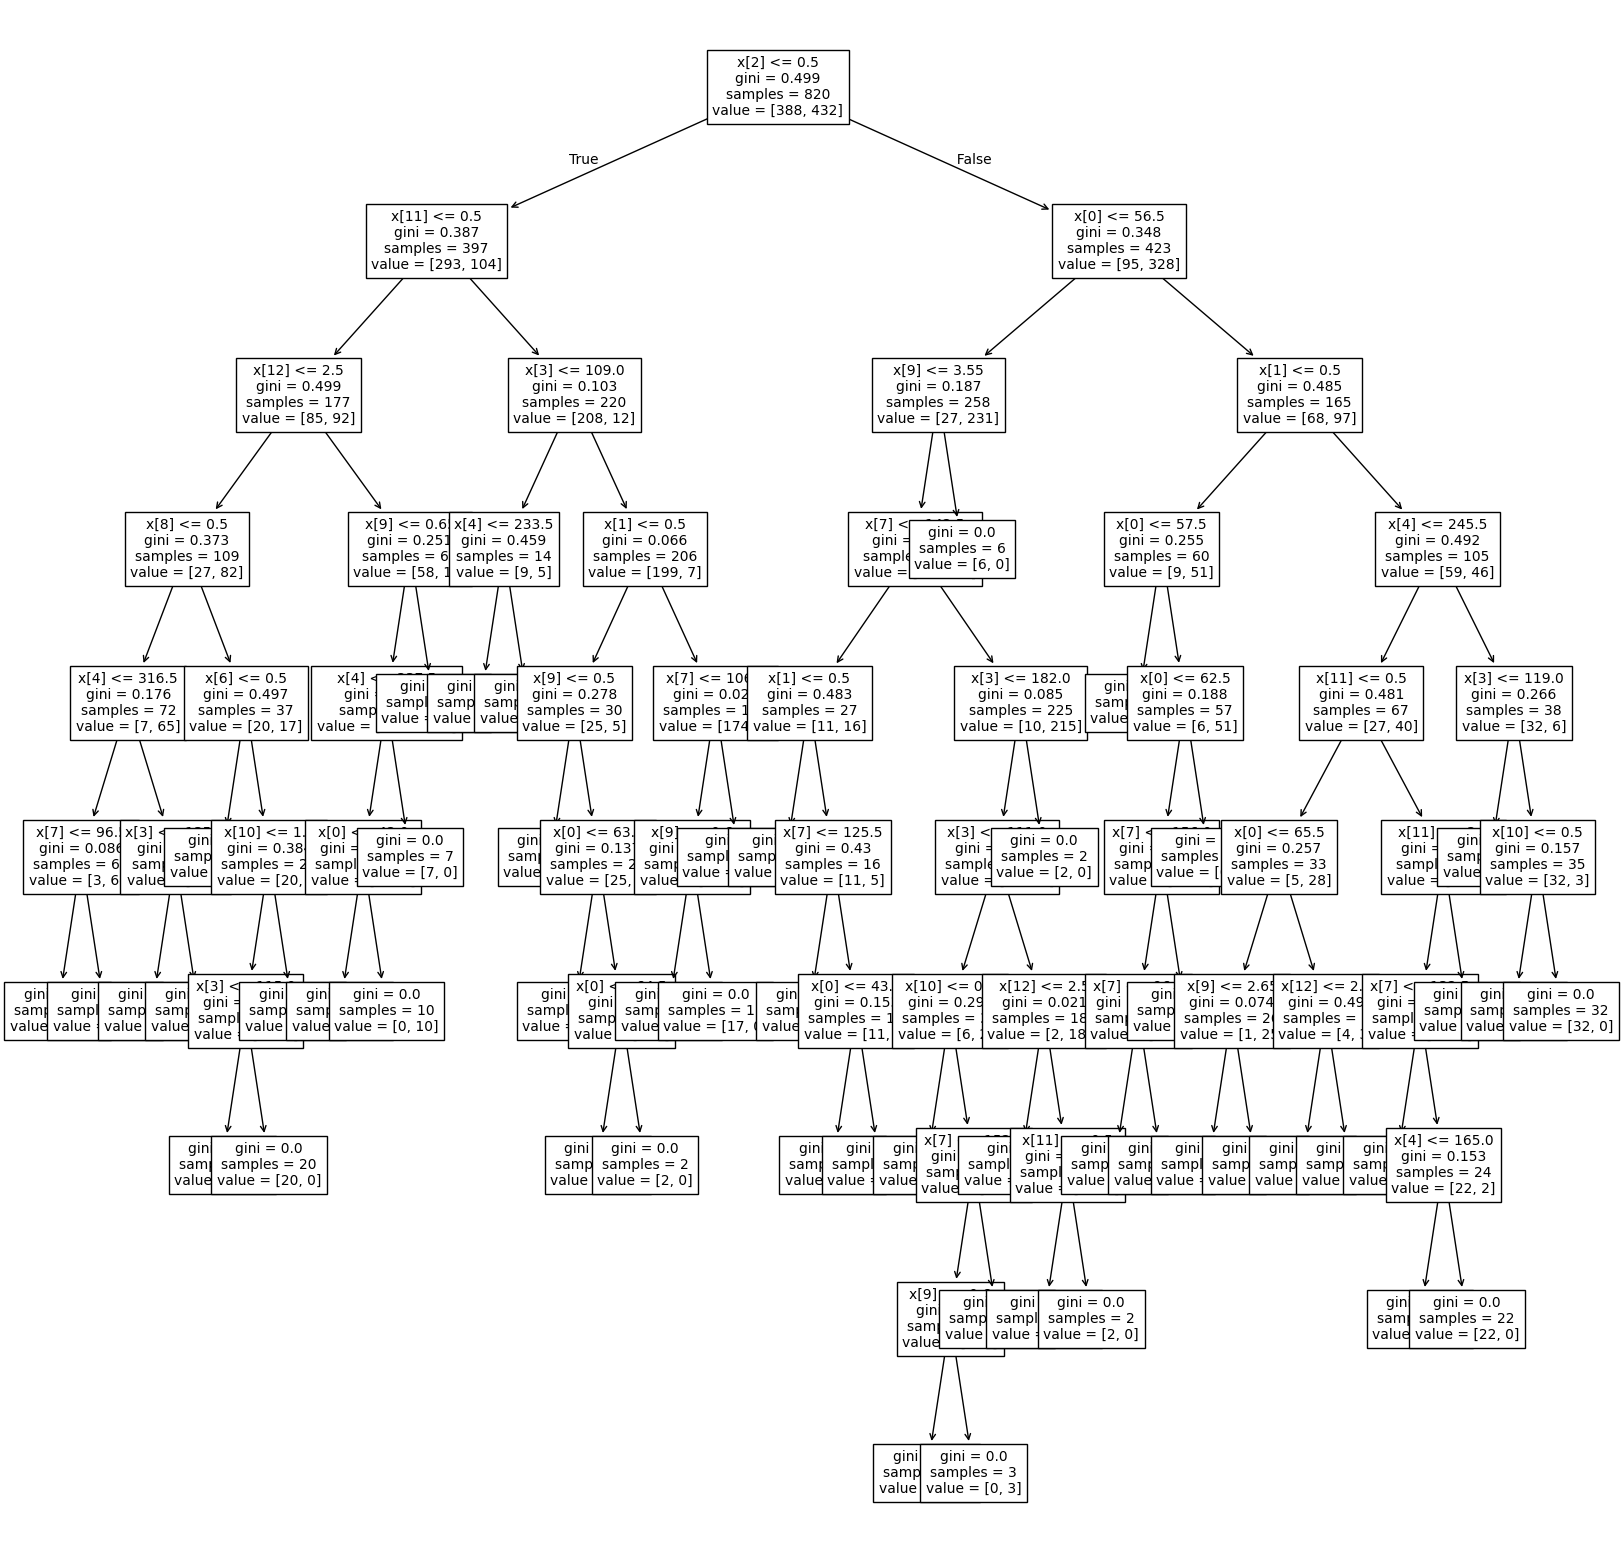

In [45]:
plt.figure(figsize=(20,20))
plt.show(tree.plot_tree(model, fontsize=10))

In [46]:
from sklearn.model_selection import GridSearchCV

In [47]:
from sklearn.tree import DecisionTreeClassifier

In [48]:
tree = DecisionTreeClassifier()

In [49]:
params={
    'max_depth':[4,5,6,7,8,9,10,11,12,13,14,15,16],
    'criterion':['gini','entropy']
}

In [50]:
cv = GridSearchCV(tree, param_grid=params, scoring = 'accuracy')

In [51]:
cv.fit(X_train, y_train)

GridSearchCV(estimator=DecisionTreeClassifier(),
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': [4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15,
                                       16]},
             scoring='accuracy')

In [52]:
cv.best_estimator_

DecisionTreeClassifier(criterion='entropy', max_depth=16)

In [53]:
cv.get_params

<bound method BaseEstimator.get_params of GridSearchCV(estimator=DecisionTreeClassifier(),
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': [4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15,
                                       16]},
             scoring='accuracy')>

In [54]:
tree= DecisionTreeClassifier(criterion='entropy', max_depth=11)

In [56]:
tree.fit(X_train, y_train)

DecisionTreeClassifier(criterion='entropy', max_depth=11)

In [57]:
from sklearn.tree import plot_tree

In [59]:
y_pred= tree.predict(X_test)

In [60]:
recall_score(y_test, y_pred)

1.0

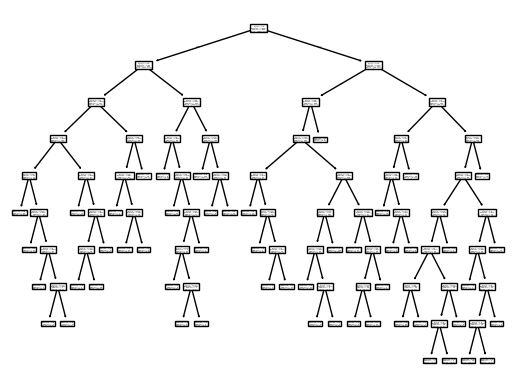

In [62]:
plt.show(plot_tree(tree))